<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana11/comparacaoknn%26decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# A BATALHA: KNN VS ÁRVORE DE DECISÃO (DIAGNÓSTICO DE CÂNCER)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("A carregar os dados médicos dos pacientes...")

# 1. Carga de Dados e Criação do DataFrame
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = pd.Series(cancer_data.target) # 0 = Maligno, 1 = Benigno

display(X.head())
display(y.head())

# 2. Divisão Estratificada (Garante que a proporção de tumores malignos vá para o teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Escalonamento Numérico
# Imprescindível para o KNN (pois usa distâncias). A Árvore não precisa, mas
# passar os dados escalonados para ela não afeta a sua lógica de quebra.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Arena pronta: Treino com {X_train.shape[0]} pacientes e Teste com {X_test.shape[0]} pacientes.")

A carregar os dados médicos dos pacientes...


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,0
0,0
1,0
2,0
3,0
4,0


Arena pronta: Treino com 455 pacientes e Teste com 114 pacientes.


In [4]:
y.value_counts()
#Se precisasse balancear, balanciasse x_train_scaled e y_train

,count
1,357
0,212


In [5]:
print("Treinando o Modelo 1: KNN (K-Nearest Neighbors)...")
# Instanciando com 5 vizinhos e matemática Euclidiana
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_model.fit(X_train_scaled, y_train)

print("Treinando o Modelo 2: Árvore de Decisão...")
# Instanciando com limite de profundidade (max_depth=4) para evitar Overfitting
arvore_model = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='gini')
arvore_model.fit(X_train_scaled, y_train)

# Colocando os modelos à prova no Mundo Real (Base de Teste)
previsoes_knn = knn_model.predict(X_test_scaled)
previsoes_arvore = arvore_model.predict(X_test_scaled)

# Comparativo de Relatórios Numéricos
print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: KNN")
print("="*50)
print(classification_report(y_test, previsoes_knn))

print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO: ÁRVORE DE DECISÃO")
print("="*50)
print(classification_report(y_test, previsoes_arvore))

Treinando o Modelo 1: KNN (K-Nearest Neighbors)...
Treinando o Modelo 2: Árvore de Decisão...

RELATÓRIO DE DESEMPENHO: KNN
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


RELATÓRIO DE DESEMPENHO: ÁRVORE DE DECISÃO
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



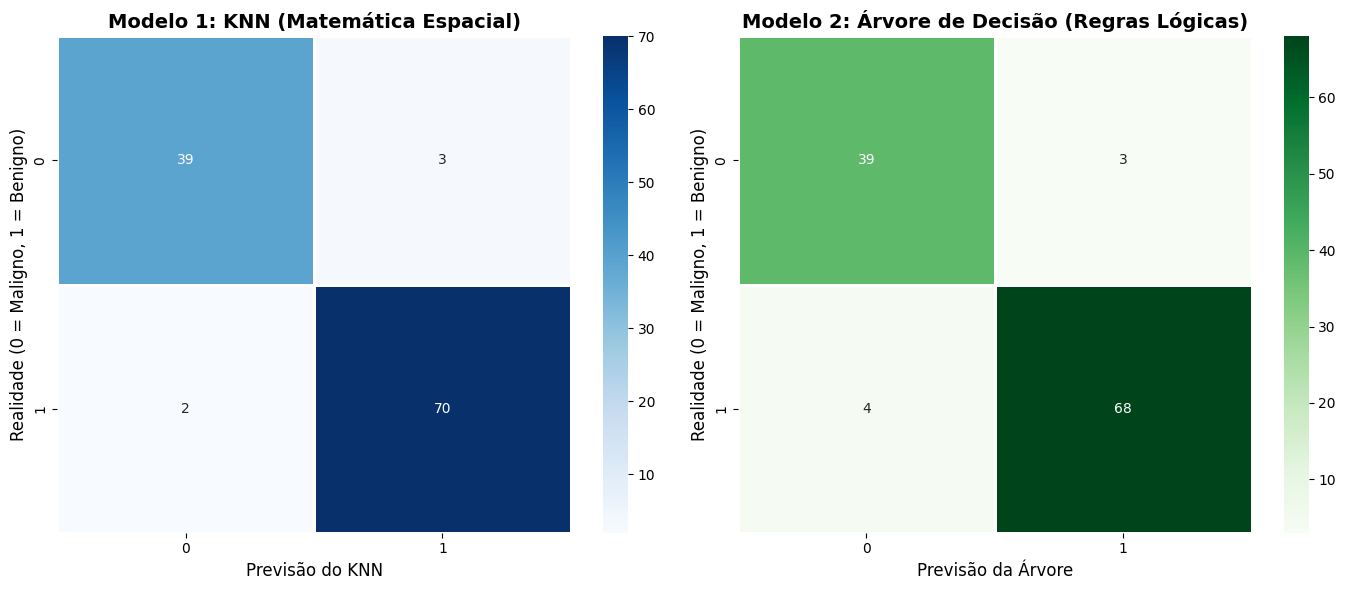

In [6]:
# Criando uma figura grande para colocar os dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- PLOT 1: Matriz do KNN ----
matriz_knn = confusion_matrix(y_test, previsoes_knn)
sns.heatmap(matriz_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=1)
axes[0].set_title('Modelo 1: KNN (Matemática Espacial)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Realidade (0 = Maligno, 1 = Benigno)', fontsize=12)
axes[0].set_xlabel('Previsão do KNN', fontsize=12)

# ---- PLOT 2: Matriz da Árvore de Decisão ----
matriz_arvore = confusion_matrix(y_test, previsoes_arvore)
sns.heatmap(matriz_arvore, annot=True, fmt='d', cmap='Greens', ax=axes[1], linewidths=1)
axes[1].set_title('Modelo 2: Árvore de Decisão (Regras Lógicas)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Realidade (0 = Maligno, 1 = Benigno)', fontsize=12)
axes[1].set_xlabel('Previsão da Árvore', fontsize=12)

# Ajustar o layout e exibir na tela
plt.tight_layout()
plt.show()